In [2]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
	'font.family': 'serif',
    'font.serif': ['cmr10'],
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (3.5, 2.625)
double_column = (7, 5.25)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [6]:
fits = [JointFitResults.load(f) for f in glob("./FNPCA joint fits with varied aperture size/*/*joint_fit.h5")]
print(fits)

2026-05-20 16:37:30,726 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



[<erebus.joint_fit_results.JointFitResults object at 0x7a0d13b5a890>, <erebus.joint_fit_results.JointFitResults object at 0x7a0d133cac10>, <erebus.joint_fit_results.JointFitResults object at 0x7a0e43393890>, <erebus.joint_fit_results.JointFitResults object at 0x7a0ddde8a510>, <erebus.joint_fit_results.JointFitResults object at 0x7a0dddea6ad0>, <erebus.joint_fit_results.JointFitResults object at 0x7a0d13394cd0>, <erebus.joint_fit_results.JointFitResults object at 0x7a0ddde79ed0>]


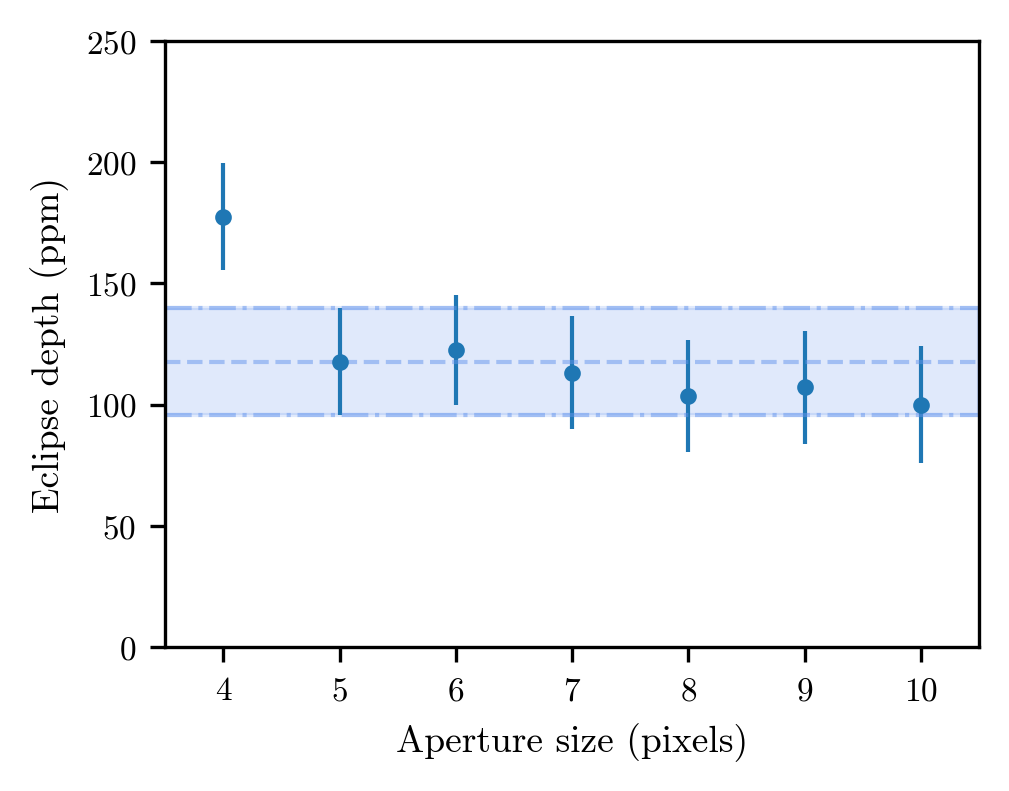

In [15]:
plt.figure(figsize=single_column)

for fit in fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']

	plt.errorbar([radius], [depth.nominal_value], [depth.std_dev], marker='.', color='C0')

d5px = fits[2].results['fp']*1e6
d = d5px.nominal_value
derr = d5px.std_dev

plt.axhspan(d - derr, d + derr, alpha=0.2, color='cornflowerblue')
plt.axhline(d, linestyle='--', color='cornflowerblue', alpha=0.5)
plt.axhline(d - derr, linestyle='-.', color='cornflowerblue', alpha=0.5)
plt.axhline(d + derr, linestyle='-.', color='cornflowerblue', alpha=0.5)

plt.xlim([3.5, 10.5])
plt.ylim([0, 250])
plt.xlabel("Aperture size (pixels)")
plt.ylabel("Eclipse depth (ppm)")
plt.savefig("figures/aperture_size.png", bbox_inches='tight')
plt.savefig("figures/aperture_size.pdf", bbox_inches='tight')

Text(0, 0.5, 'Eclipse time relative to 0.5 phase (min)')

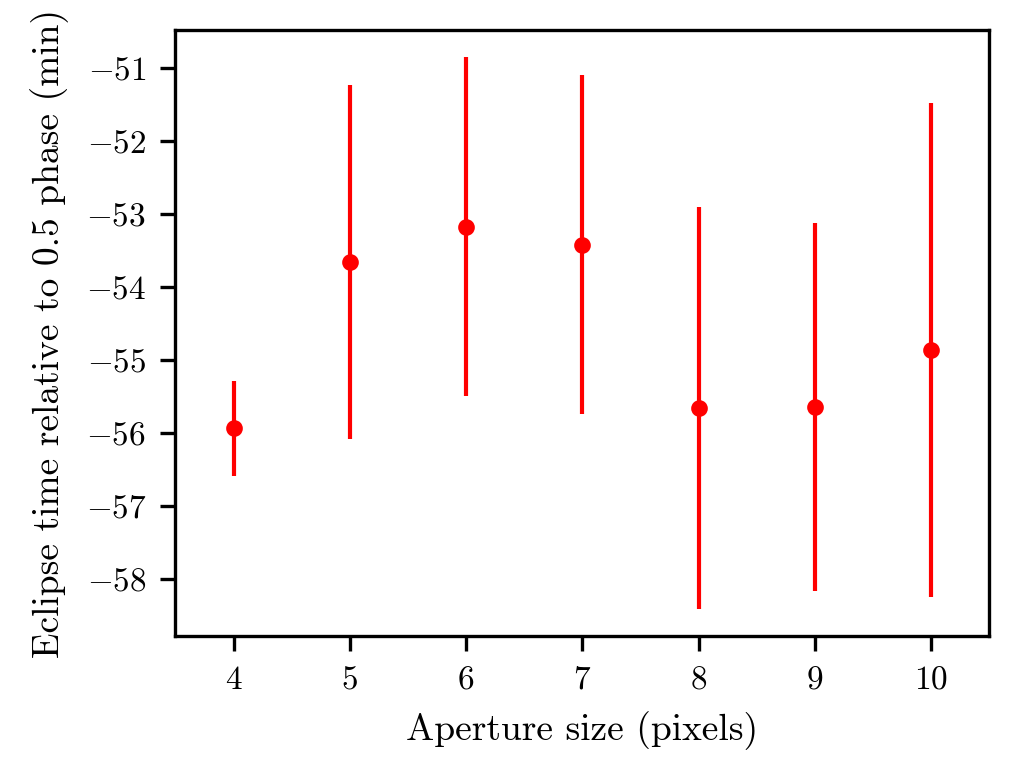

In [13]:
plt.figure(figsize=single_column)

for fit in fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']*24*60

	plt.errorbar([radius], [t_sec.nominal_value], [t_sec.std_dev], marker='.', color='red')

plt.xlim([3.5, 10.5])
plt.xlabel("Aperture size (pixels)")
plt.ylabel("Eclipse time relative to 0.5 phase (min)")

(3.5, 10.5)

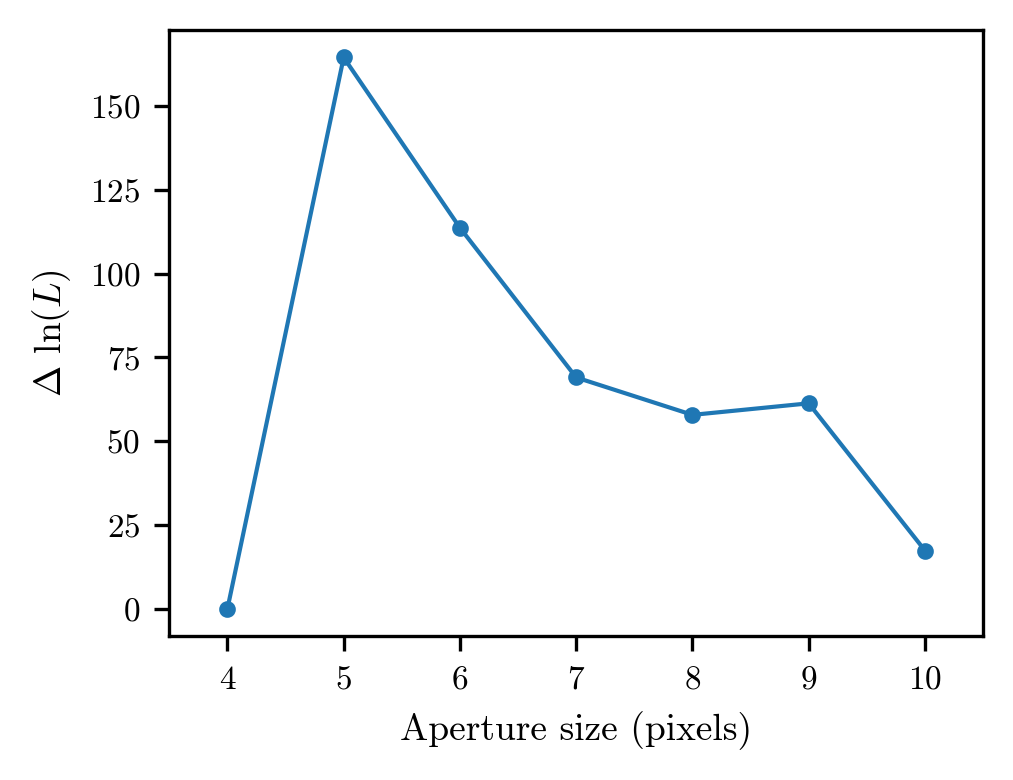

In [14]:
plt.figure(figsize=single_column)

radius = np.array([fit.config['aperture_radius'] for fit in fits])
bics = np.array([fit.final_log_likelihood for fit in fits])
s = np.argsort(radius)
radius = radius[s]
bics = bics[s]

plt.plot(radius, bics - np.min(bics), marker='.')
plt.xlabel("Aperture size (pixels)")
plt.ylabel(r"$\Delta$ ln($L$)")
plt.xlim([3.5, 10.5])

In [10]:
def make_latex_table(data, headers):
	data = np.array(data)
	lines = []
	lines.append(r"\begin{table}[h]")
	lines.append(r"    \centering")
	lines.append(r"        \begin{tabular}{cccc}")
	lines.append(r"        \hline")
	lines.append(f"        {' & '.join(headers)} \\\\")
	lines.append(r"        \hline")
	
	for row in data.T:
		lines.append(f"        {' & '.join(str(x) for x in row)} \\\\")
	
	lines.append(r"        \hline")
	lines.append(r"    \end{tabular}")
	lines.append(r"\end{table}")
	
	return "\n".join(lines)

headers = ["Radius (px)", "$f_p/f_\star$ (ppm)", "$\Delta t_{sec}$ (hrs)", "$\Delta$ log likelihood"]
radius = np.array([fit.config['aperture_radius'] for fit in fits])
bics = np.array([fit.final_log_likelihood for fit in fits])
depths = np.array([fit.results['fp']*1e6 for fit in fits])
timings = np.array([fit.results['t_sec_offset']*24*60 for fit in fits])


s = np.argsort(radius)
radius = radius[s]
bics = bics[s]
depths = depths[s]
timings = timings[s]

# Format
depths = [f"${d.nominal_value:.0f} \pm {d.std_dev:.0f}$" for d in depths]
timings = [f"${d.nominal_value:.0f} \pm {d.std_dev:.1f}$" for d in timings]
bics = bics - np.max(bics)
bics = [f"{b:.0f}" for b in bics]

print(make_latex_table([radius, depths, timings, bics], headers))

\begin{table}[h]
    \centering
        \begin{tabular}{cccc}
        \hline
        Radius (px) & $f_p/f_\star$ (ppm) & $\Delta t_{sec}$ (hrs) & $\Delta$ log likelihood \\
        \hline
        4 & $177 \pm 22$ & $-56 \pm 0.6$ & -165 \\
        5 & $118 \pm 22$ & $-54 \pm 2.4$ & 0 \\
        6 & $123 \pm 23$ & $-53 \pm 2.3$ & -51 \\
        7 & $113 \pm 23$ & $-53 \pm 2.3$ & -95 \\
        8 & $104 \pm 23$ & $-56 \pm 2.7$ & -107 \\
        9 & $107 \pm 23$ & $-56 \pm 2.5$ & -103 \\
        10 & $100 \pm 24$ & $-55 \pm 3.4$ & -147 \\
        \hline
    \end{tabular}
\end{table}
